<a href="https://colab.research.google.com/github/theliferacer/A-simple-trading-strategy/blob/main/Quant_Project_Basis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from scipy.optimize import minimize

In [ ]:
tickers = ["SPY", "TLT", "GLD", "AAPL", "XOM"]

start_date = datetime.datetime(2015, 1, 1)
end_date = datetime.datetime(2015, 12, 31)

data = pd.DataFrame()

for ticker in tickers:
    stock_data = yf.download(ticker, start = start_date, end = end_date)
    data[ticker] = stock_data["Close"]

/tmp/ipython-input-53-3327273732.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start = start_date, end = end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-53-3327273732.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start = start_date, end = end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-53-3327273732.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start = start_date, end = end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-53-3327273732.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start = start_date, end = end_date)
[*********************100%***************

In [ ]:
log_returns = pd.DataFrame()
for ticker in tickers:
    log_returns[ticker] = np.log(data[ticker]/data[ticker].shift(1))

num_assets = log_returns.shape[1]

# Random Possible Portfolios

In [ ]:
from math import log
np.random.seed(42)
ret_arr = []
vol_arr = []
shr_arr = []
all_weights = []

mean_arr = log_returns.mean()*252
cov_matrix = log_returns.cov()*252

for i in range(10000):
  weights = np.array(np.random.random(5))
  weights = weights/np.sum(weights)

  all_weights.append(weights)

  ret = np.dot(weights.T, mean_arr)
  ret_arr.append(ret)

  var = np.dot(weights.T, np.dot(cov_matrix, weights))
  vol_arr.append(np.sqrt(var))

  shr_arr.append(ret/np.sqrt(var))

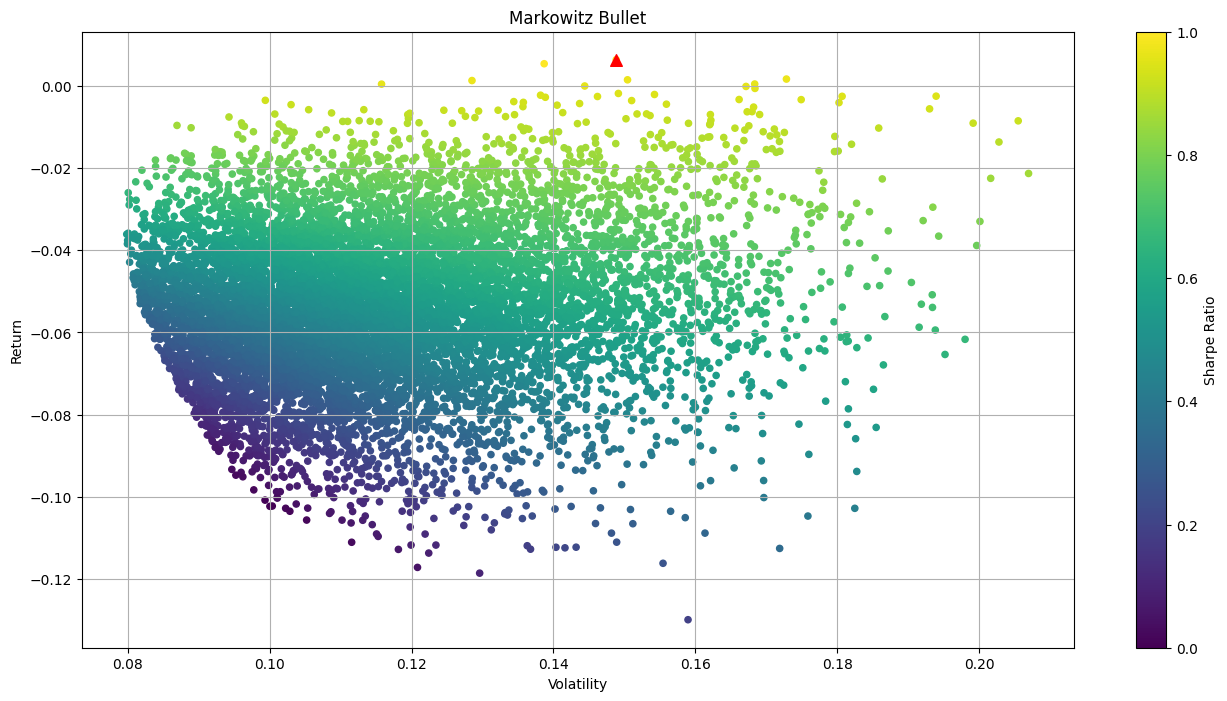

0.042977862283218614


In [ ]:
max_sr_ret = ret_arr[np.array(shr_arr).argmax()]
max_sr_vol = vol_arr[np.array(shr_arr).argmax()]

plt.figure(figsize=(16,8))
plt.scatter(vol_arr, ret_arr, c = shr_arr, cmap = "viridis", s = 20)
plt.scatter(max_sr_vol, max_sr_ret, color = "red", s = 70, marker = "^")
plt.colorbar(label = "Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Markowitz Bullet")
plt.grid(True)
plt.show()

print(shr_arr[np.array(shr_arr).argmax()])

In [ ]:
def ret_vol_sr(weights):
  ret_mean = log_returns.mean()*252
  cov_matrix = log_returns.cov()*252

  ret = np.dot(weights.T, ret_mean)
  vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

  sr = ret/vol
  return [ret, vol, sr]

In [ ]:
#constraints
def sum_weights(weights):
  return sum(weights) - 1

In [ ]:
def minimize_vol(weights):
  return ret_vol_sr(weights)[1]

def neg_sr(weights):
  return -ret_vol_sr(weights)[2]

In [ ]:
portfolio_y = np.linspace(0, 0.35, 500) #possible returns
portfolio_x = [] #corresponding minimized volatilities
optimized_weights = []

for exp_return in portfolio_y:
  #Efficient Frontier
  cons = ({"type": "eq", "fun": sum_weights},
          {"type": "eq", "fun": lambda w: ret_vol_sr(w)[0] - exp_return})
  init_guess = [1/5]*num_assets
  bounds = [(0,1)]*num_assets
  result = minimize(minimize_vol, init_guess, method = "SLSQP", constraints = cons, bounds = bounds)
  if result.success:
    portfolio_x.append(result.fun)
    optimized_weights.append(result.x)
  else:
    print(f"Optimization for expected return = {exp_return} failed")

Optimization for expected return = 0.0 failed
Optimization for expected return = 0.0007014028056112224 failed
Optimization for expected return = 0.0014028056112224449 failed


KeyboardInterrupt: 

In [ ]:
portfolio_sr = portfolio_y/portfolio_x

#Max sharpe ratio index - tangency portfolio
ind = np.array(portfolio_sr).argmax()

tangency_x = portfolio_x[ind]
tangency_y = portfolio_y[ind]
tangency_weights = optimized_weights[ind].round(4)
tangency_weights

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(portfolio_x, portfolio_y, color = "red", linewidth = 3, linestyle = "--")
plt.scatter(vol_arr, ret_arr, c = shr_arr, cmap = "viridis", s = 20)
plt.scatter(tangency_x, tangency_y, color= "blue", s = 100, marker = "^")
plt.colorbar(label = "Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Markowitz Bullet")
plt.grid(True)
plt.show()

# What is the best portfolio now?
**Multiple answers, based on what you are trying to achieve**

##If you want max sharpe ration
--> Choose the tangency portfolio, the large blue triangle

In [ ]:
print("The portfolio with max sharpe ratio, is the tangecncy portfolio with the following weights allocation \n")
for i, ticker in enumerate(tickers):
  print(f"{tangency_weights[i]*100} % in {ticker}\n")
print("The Sharpe ratio, Expected Return and Volatility of this portfolio is \n")
tangency_portfolio = ret_vol_sr(tangency_weights)
print(f"Expected Return: {float(tangency_portfolio[0]): .4}")
print(f"Volatility: {float(tangency_portfolio[1]): .4}")
print(f"Sharpe Ratio: {float(tangency_portfolio[2]): .4}")

## If one is aiming for an Expected Return
--> Can use optimize funtion, or use lagrange multiples to find optimal weights, that minimize the volatility

In [ ]:
def lagrange_weights(target_return):
  #Lagrange Method
  cov_inv = np.linalg.inv(cov_matrix)
  A = np.dot(mean_arr.T, np.dot(cov_inv, mean_arr))
  B = np.dot(mean_arr.T, np.dot(cov_inv, np.ones(num_assets)))
  C = np.dot(np.ones(num_assets).T, np.dot(cov_inv, np.ones(num_assets)))

  lhs = [[A, B], [B, C]]
  rhs = [target_return, 1]
  lambdas = np.linalg.solve(lhs, rhs)

  weights = np.dot(cov_inv, lambdas[0]*mean_arr + lambdas[1]*np.ones(num_assets))

  return weights

In [ ]:
target_return = 0.457
target_weights = lagrange_weights(target_return).round(4)

print("The portfolio with minimized volatility for given expected return has the following weights allocation \n")
for i, ticker in enumerate(tickers):
  print(f"{target_weights[i]*100} % in {ticker}\n")
print("The Sharpe ratio, Expected Return and Volatility of this portfolio is \n")
lagrange_portfolio = ret_vol_sr(target_weights)
print(f"Expected Return: {float(lagrange_portfolio[0]): .4}")
print(f"Volatility: {float(lagrange_portfolio[1]): .4}")
print(f"Sharpe Ratio: {float(lagrange_portfolio[2]): .4}")

#Backtesting - Rolling window analysis

In [ ]:
start_date1 = datetime.datetime(2010, 1, 1)
end_date1 = datetime.datetime(2023, 12, 31)

full_data = pd.DataFrame()

for ticker in tickers:
    stock_data = yf.download(ticker, start = start_date1, end = end_date1)
    full_data[ticker] = stock_data["Close"]


new_log_returns = pd.DataFrame()
for ticker in tickers:
  new_log_returns[ticker] = np.log(full_data[ticker]/full_data[ticker].shift(1))

In [ ]:
def ret_vol_shr(weights, mean_arr, cov_matrix):
  ret = np.dot(weights.T, mean_arr)
  vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
  shr = ret/vol
  return [ret, vol, shr]

def shr_negative(weights, mean_arr, cov_matrix):
  return -ret_vol_shr(weights, mean_arr, cov_matrix)[2]

In [ ]:
hist_mean = new_log_returns[:252].mean()*252 #past 252 days mean
hist_cov = new_log_returns[:252].cov()*252 #past 252 days cov matrix

#Choosing tangency portfolio for max sharpe ration
weights = tangency_weights

port_ret_arr = [] #array of portfolio returns
port_vol_arr = [] #array of portfolio volatilities
cum_ret_arr = [] #array of cumulative returns
cum = 0
count = 0

for i in range(252, new_log_returns.shape[0], 21): #every 21 days, change the tangency portfolio weights
  monthly_mean = new_log_returns[i : i+21].mean()*21
  monthly_cov = new_log_returns[i : i+21].cov()*21

  portfolio_ret = np.dot(weights.T, monthly_mean)
  portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(monthly_cov, weights)))
  cum += np.exp(portfolio_ret)

  port_ret_arr.append(np.exp(portfolio_ret))
  port_vol_arr.append(portfolio_vol)
  cum_ret_arr.append(cum)

  count += 1
  #Now time to update portfolio weights
  hist_mean = new_log_returns[i-252: i].mean()*252 #past 252 days mean
  hist_cov = new_log_returns[i-252: i].cov()*252 #past 252 days cov

  #optimization
  cons = ({"type":"eq", "fun": sum_weights})
  bounds = [(0,1)]*num_assets
  init_guess = [1/num_assets]*num_assets

  result = minimize(shr_negative, init_guess, args= (hist_mean, hist_cov), method = "SLSQP", constraints = cons, bounds = bounds)
  if result.success:
    weights = result.x
  else:
    print(f"Optimizing Sharpe Ratio for {count}th month failed")

In [ ]:
plt.figure(figsize = [10,7])
plt.plot(port_ret_arr)

In [ ]:
plt.figure(figsize = [10,7])
plt.plot(cum_ret_arr)